## Imports

In [6]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    import gdown
    drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import io
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, pearsonr, kendalltau
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from pathlib import Path
import pandas as pd

## Setup
Loading data,
Memory management,
Constants

In [8]:
# Training file
train_file_id = "1hT51HoLUSZohAl4CRIRopnh0gqnj8Pz4"
train_output = 'train_sampled_esm2_650m.pt'
gdown.download(f'https://drive.google.com/uc?id={train_file_id}', train_output, quiet=False)
train_path = Path(train_output)

# Validation file
val_file_id = "1H0lC_7G0cwr8hB0dMyrWf7tcEUB8oB4e"
val_output = 'val_full_esm2_650m.pt'
gdown.download(f'https://drive.google.com/uc?id={val_file_id}', val_output, quiet=False)
val_path = Path(val_output)

# All sequence file
raw_file_id = "13j3-jBOsLweSQhU-7qcApWfcLyUNo30FjrMSZUxVMMo"
raw_output = 'all_sequences.csv'
gdown.download(f'https://drive.google.com/uc?id={raw_file_id}', raw_output, quiet=False)
raw_path = Path(raw_output)

Downloading...
From (original): https://drive.google.com/uc?id=1hT51HoLUSZohAl4CRIRopnh0gqnj8Pz4
From (redirected): https://drive.google.com/uc?id=1hT51HoLUSZohAl4CRIRopnh0gqnj8Pz4&confirm=t&uuid=9d1a75e6-3fcf-4780-becb-b6aaf21e9788
To: /content/train_sampled_esm2_650m.pt
100%|██████████| 313M/313M [00:07<00:00, 43.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1H0lC_7G0cwr8hB0dMyrWf7tcEUB8oB4e
From (redirected): https://drive.google.com/uc?id=1H0lC_7G0cwr8hB0dMyrWf7tcEUB8oB4e&confirm=t&uuid=69f60781-de22-41c0-b166-977c81166ccd
To: /content/val_full_esm2_650m.pt
100%|██████████| 296M/296M [00:06<00:00, 46.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=13j3-jBOsLweSQhU-7qcApWfcLyUNo30FjrMSZUxVMMo
From (redirected): https://docs.google.com/spreadsheets/d/13j3-jBOsLweSQhU-7qcApWfcLyUNo30FjrMSZUxVMMo/export?format=xlsx
To: /content/all_sequences.csv
3.04MB [00:01, 2.38MB/s]


In [9]:
# Memory management to prevent crashing
def convert_to_memmap(pt_path, out_mmap_path):
    data_obj = robust_pt_load(pt_path)
    emb_array = np.array(data_obj['seq_embeddings'], dtype=np.float32)
    shape = emb_array.shape

    np.save(f"{out_mmap_path}_shape.npy", np.array(shape))

    fp = np.memmap(out_mmap_path, dtype='float32', mode='w+', shape=shape)
    fp[:] = emb_array[:]
    fp.flush()

    del fp
    check = np.memmap(out_mmap_path, dtype='float32', mode='r', shape=shape)
    assert check.shape == shape, f"Memmap shape mismatch for {out_mmap_path}"
    print(f"Successfully converted {pt_path} to memmap at {out_mmap_path} with shape {shape}")
    return data_obj

In [10]:
# Model constants
INPUT_DIM = 1280
LATENT_DIM = 256
HIDDEN_DIM = 512

NUM_EPOCHS = 100
BATCH_SIZE = 128
PATIENCE = 7
LEARNING_RATE = 8e-5
DROPOUT_RATE = 0.2
WEIGHT_DECAY = 2e-6

RL_WEIGHT = 1.0
KL_WEIGHT = 0.2
PL_WEIGHT = 0.1
SEQ_WEIGHT = 1.0

OPTIM_STEPS = 25
OPTIM_LR = 0.05
AA_VOCAB = {aa: i for i, aa in enumerate("ACDEFGHIKLMNPQRSTVWY")}

VOCAB_SIZE = len(AA_VOCAB) + 1  # 20 AAs + 1 for padding/unknown

## Robust Loader

In [11]:
# Safety utility for loading PyTorch files
def robust_pt_load(path):
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except Exception:
        import pickle
        class CPU_Unpickler(pickle.Unpickler):
            def find_class(self, module, name):
                if module == 'torch.storage' and name == '_load_from_bytes':
                    return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
                return super().find_class(module, name)
        with open(path, 'rb') as f:
            return CPU_Unpickler(f).load()

## Dataset Class

In [12]:
class ProteinDataset(Dataset):
    def __init__(self, pt_path, mmap_path, scaler=None):
        print(f"Loading Dataset: {pt_path}")
        data_obj = robust_pt_load(pt_path)

        shape = tuple(np.load(f"{mmap_path}_shape.npy"))
        self.embeddings = np.memmap(mmap_path, dtype='float32', mode='r', shape=shape)

        labels_np = np.array(data_obj['delta_g']).reshape(-1, 1)
        self.clusters = np.array(data_obj['wt_cluster'])
        # Normalize mutation types for easier matching
        self.mut_types = [str(m).lower().strip() for m in data_obj['mut_type']]

        if 'aa_seq' in data_obj:
            self.sequences = data_obj['aa_seq']
        elif 'aa_seq_full' in data_obj:
            self.sequences = data_obj['aa_seq_full']
        else:
            self.sequences = ["" for _ in range(len(self.embeddings))]

        self.wt_lookup = {}
        # First pass: find explicit WT entries
        for i, mtype in enumerate(self.mut_types):
            if mtype in ['wt', 'wildtype', 'wild-type']:
                self.wt_lookup[self.clusters[i]] = {
                    'dg': labels_np[i][0],
                    'emb': self.embeddings[i],
                    'seq': self.sequences[i]
                }

        # Second pass: Fallback for clusters without an explicit WT
        all_unique_clusters = np.unique(self.clusters)
        for c in all_unique_clusters:
            if c not in self.wt_lookup:
                idx = np.where(self.clusters == c)[0][0]
                self.wt_lookup[c] = {
                    'dg': labels_np[idx][0],
                    'emb': self.embeddings[idx],
                    'seq': self.sequences[idx]
                }

        if scaler is None:
            self.scaler = StandardScaler()
            self.labels_scaled = self.scaler.fit_transform(labels_np)
        else:
            self.scaler = scaler
            self.labels_scaled = self.scaler.transform(labels_np)

        self.labels_scaled = torch.from_numpy(self.labels_scaled).float()

    def __len__(self):
        return self.embeddings.shape[0]

    def __getitem__(self, idx):
        return {
            'emb': torch.from_numpy(np.array(self.embeddings[idx])).float(),
            'label_scaled': self.labels_scaled[idx]
        }

In [13]:
# Decoder for dream, compares wildtype against gen mut
def batch_decode_and_count_mutations(logits, wt_seqs):
    """
    Vectorized decoding and mutation counting for a batch of sequences.
    """
    inv_vocab = {v: k for k, v in AA_VOCAB.items()}
    # Get most likely amino acid indices for the whole batch: [Batch, Len]
    indices = torch.argmax(logits, dim=-1)

    batch_results = []
    for i, wt_seq in enumerate(wt_seqs):
        length = len(wt_seq)
        # Extract the generated indices for this specific sequence length
        seq_indices = indices[i, :length]

        generated_seq = ""
        mutations = 0
        for j in range(length):
            char = inv_vocab.get(seq_indices[j].item(), 'X')
            generated_seq += char
            if char != wt_seq[j]:
                mutations += 1
        batch_results.append((generated_seq, mutations))

    return batch_results

In [14]:
def optimize_latent_constrained(model, emb, base_seq=None, steps=25, lr=0.05, max_dist=0.1, lambda_weight=0.5):
    """
    Optimizes a latent vector using a squared soft Hamming constraint:
    L = -Regressor(z) + lambda * (soft_hamming - 1)^2
    """
    model.eval()
    with torch.no_grad():
        h = model.encoder(emb)
        z_start = h[:, :model.latent_dim].detach()

    z_opt = z_start.clone().requires_grad_(True)
    optimizer = optim.Adam([z_opt], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        # We minimize, so we use -Regressor(z) to maximize the predicted deltaG (or stabilize)
        # If higher is better, use -pred; if lower is better (stabilizing), use +pred.
        # Based on previous code, pred_y.mean() was used, assuming we minimize deltaG.
        pred_y = model.regressor(z_opt)

        # Latent proximity to stay in distribution
        dist_loss = torch.norm(z_opt - z_start, p=2, dim=1).mean()

        total_loss = pred_y.mean() + (max_dist * dist_loss)

        if base_seq is not None:
            recon_emb = model.decoder(z_opt)
            seq_hidden = model.seq_proj(recon_emb).view(-1, model.max_seq_len, 64)
            logits = model.seq_out(seq_hidden)

            target_len = len(base_seq)
            sliced_logits = logits[:, :target_len, :]
            target_indices = torch.tensor([AA_VOCAB.get(aa, 20) for aa in base_seq], device=z_opt.device).unsqueeze(0)

            probs = F.softmax(sliced_logits, dim=-1)
            wt_probs = torch.gather(probs, 2, target_indices.unsqueeze(-1)).squeeze(-1)

            # soft_hamming = sum(1 - P(wt_i))
            soft_hamming_dist = (1.0 - wt_probs).sum()

            # Apply the constraint: lambda * (soft_hamming - 1)^2
            constraint_penalty = lambda_weight * torch.pow(soft_hamming_dist - 1.0, 2)
            total_loss += constraint_penalty

        total_loss.backward()
        optimizer.step()

    return z_opt.detach()

## Protein VAE Model

In [15]:
class ProteinVAE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, max_seq_len=100, dropout=0.2):
        super(ProteinVAE, self).__init__()
        self.latent_dim = latent_dim
        self.max_seq_len = max_seq_len

        # Encoder now takes the embedding as input
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, latent_dim * 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

        # Projection to sequence logits using the database max_seq_len
        self.seq_proj = nn.Linear(input_dim, max_seq_len * 64)
        self.seq_out = nn.Linear(64, 21)

        self.regressor = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = h[:, :self.latent_dim], h[:, self.latent_dim:]
        z = self.reparameterize(mu, logvar)
        recon_emb = self.decoder(z)

        # Map reconstructed embedding to sequence logits
        seq_features = self.seq_proj(recon_emb).view(-1, self.max_seq_len, 64)
        recon_seq_logits = self.seq_out(seq_features)

        pred_y = self.regressor(z)
        return recon_emb, recon_seq_logits, pred_y, mu, logvar

## Optimisation

In [16]:
def optimize_latent(model, emb, steps=OPTIM_STEPS, lr=OPTIM_LR):
    """
    Fixed version: Passes latent vector z directly to the regressor
    to match the ProteinVAE architecture and the constrained optimizer.
    """
    model.eval()

    with torch.no_grad():
        h = model.encoder(emb)
        z_start = h[:, :model.latent_dim].detach()

    z_opt = z_start.clone().requires_grad_(True)
    optimizer = optim.Adam([z_opt], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        pred_y = model.regressor(z_opt)
        loss = pred_y.mean() + KL_WEIGHT * torch.pow(z_opt, 2).mean()
        loss.backward()
        optimizer.step()

    return z_opt.detach()

## Training/Evaluation Pipelines

In [17]:
def seq_to_tensor(seqs, max_len, device):
    """Converts amino acid sequences to padded tensors of indices. Pads with index 20 (X)."""
    tensor = torch.full((len(seqs), max_len), 20, dtype=torch.long, device=device)
    for i, seq in enumerate(seqs):
        indices = [AA_VOCAB.get(aa.upper(), 20) for aa in seq[:max_len]]
        tensor[i, :len(indices)] = torch.tensor(indices, device=device)
    return tensor

def train_and_validate(config, train_path, train_mmap, val_path, val_mmap, epochs=NUM_EPOCHS, patience=PATIENCE):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_ds = ProteinDataset(train_path, train_mmap)
    val_ds = ProteinDataset(val_path, val_mmap, scaler=train_ds.scaler)

    db_max_len = max(max(len(s) for s in train_ds.sequences), max(len(s) for s in val_ds.sequences))
    print(f"Setting model max_seq_len to database maximum: {db_max_len}")

    train_loader = DataLoader(train_ds, batch_size=config.get('BATCH_SIZE', BATCH_SIZE), shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=config.get('BATCH_SIZE', BATCH_SIZE), shuffle=False, num_workers=0)

    model = ProteinVAE(
        input_dim=INPUT_DIM,
        latent_dim=config.get('LATENT_DIM', LATENT_DIM),
        hidden_dim=config.get('HIDDEN_DIM', HIDDEN_DIM),
        max_seq_len=db_max_len
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=config.get('LEARNING_RATE', LEARNING_RATE), weight_decay=config.get('WEIGHT_DECAY', WEIGHT_DECAY))
    mse_loss_fn = nn.MSELoss()

    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for batch in train_loader:
            embs = batch['emb'].to(device)
            labels = batch['label_scaled'].to(device)

            optimizer.zero_grad()
            recon_emb, recon_seq_logits, pred_y, mu, logvar = model(embs)

            recon_loss = mse_loss_fn(recon_emb, embs)
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            pred_loss = mse_loss_fn(pred_y, labels)

            loss = recon_loss + 0.1 * kl_loss + pred_loss
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in val_loader:
                embs = batch['emb'].to(device)
                labels = batch['label_scaled'].to(device)
                _, _, pred_y, _, _ = model(embs)
                val_loss += mse_loss_fn(pred_y, labels).item()
                all_preds.append(pred_y.cpu().numpy())
                all_labels.append(labels.cpu().numpy())

        avg_val = val_loss / len(val_loader)
        preds_final = val_ds.scaler.inverse_transform(np.vstack(all_preds)).flatten()
        labels_final = val_ds.scaler.inverse_transform(np.vstack(all_labels)).flatten()

        rmse = np.sqrt(mean_squared_error(labels_final, preds_final))
        r2 = r2_score(labels_final, preds_final)
        tau, _ = kendalltau(labels_final, preds_final)

        print(f"Epoch {epoch}: Val Loss = {avg_val:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f} | Kendall Tau: {tau:.4f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience: break

    return model, train_ds, val_ds

## Running the model

In [18]:
train_mmap = 'train_mmap.bin'
val_mmap = 'val_mmap.bin'

if not Path(train_mmap).exists():
    convert_to_memmap(train_path, train_mmap)
if not Path(val_mmap).exists():
    convert_to_memmap(val_path, val_mmap)

default_config = {
    'LEARNING_RATE': LEARNING_RATE,
    'LATENT_DIM': LATENT_DIM,
    'HIDDEN_DIM': HIDDEN_DIM,
    'BATCH_SIZE': BATCH_SIZE,
    'SEQ_WEIGHT': SEQ_WEIGHT,
    'KL_WEIGHT': KL_WEIGHT,
    'WEIGHT_DECAY': WEIGHT_DECAY
}

# Capture returns to use in evaluation cell
model, train_ds, val_ds = train_and_validate(default_config, train_path, train_mmap, val_path, val_mmap, epochs=100)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Successfully converted train_sampled_esm2_650m.pt to memmap at train_mmap.bin with shape (60000, 1280)
Successfully converted val_full_esm2_650m.pt to memmap at val_mmap.bin with shape (56731, 1280)
Loading Dataset: train_sampled_esm2_650m.pt
Loading Dataset: val_full_esm2_650m.pt
Setting model max_seq_len to database maximum: 74
Epoch 1: Val Loss = 0.5300 | RMSE: 1.5166 | R2: 0.3955 | Kendall Tau: 0.4454
Epoch 2: Val Loss = 0.4383 | RMSE: 1.3793 | R2: 0.5000 | Kendall Tau: 0.5240
Epoch 3: Val Loss = 0.4018 | RMSE: 1.3206 | R2: 0.5416 | Kendall Tau: 0.5472
Epoch 4: Val Loss = 0.3939 | RMSE: 1.3075 | R2: 0.5507 | Kendall Tau: 0.5514
Epoch 5: Val Loss = 0.3979 | RMSE: 1.3140 | R2: 0.5462 | Kendall Tau: 0.5550
Epoch 6: Val Loss = 0.3874 | RMSE: 1.2966 | R2: 0.5581 | Kendall Tau: 0.5648
Epoch 7: Val Loss = 0.3619 | RMSE: 1.2533 | R2: 0.5871 | Kendall Tau: 0.5739
Epoch 8: Val Loss = 0.3559 | RMSE: 1.2427 | R2: 0.5941 | Kendall Tau: 0.5797
Epoch 9: Val Loss = 0.3424 | RMSE: 1.2190 | R2: 0.60

In [19]:
import random
from sklearn.utils import resample

def run_unified_evaluation(model, val_loader, dataset, device, master_lookup, num_samples=1000, n_bootstraps=10):
    model.eval()
    all_preds = []
    all_labels = []

    print(f"--- Dataset Sizes ---")
    print(f"Total training samples:   {len(train_ds)}")
    print(f"Total validation samples: {len(val_ds)}")

    # 1. Collect all predictions for the validation set
    with torch.no_grad():
        for batch in val_loader:
            embs = batch['emb'].to(device)
            labels = batch['label_scaled'].to(device)
            h = model.encoder(embs)
            z = h[:, :model.latent_dim]
            preds_scaled = model.regressor(z)
            all_preds.append(preds_scaled.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    preds_scaled_np = np.vstack(all_preds)
    labels_scaled_np = np.vstack(all_labels)
    preds_final = dataset.scaler.inverse_transform(preds_scaled_np).flatten()
    labels_final = dataset.scaler.inverse_transform(labels_scaled_np).flatten()

    # 2. Bootstrapping for Uncertainties
    metrics_boot = {'rmse': [], 'r2': [], 'tau': []}

    for i in range(n_bootstraps):
        p_boot, l_boot = resample(preds_final, labels_final, replace=True, random_state=i)
        metrics_boot['rmse'].append(np.sqrt(mean_squared_error(l_boot, p_boot)))
        metrics_boot['r2'].append(r2_score(l_boot, p_boot))
        metrics_boot['tau'].append(kendalltau(l_boot, p_boot)[0])

    print(f"\n--- Global Validation Metrics ({n_bootstraps} bootstraps) ---")
    print(f"RMSE:          {np.mean(metrics_boot['rmse']):.4f} ± {np.std(metrics_boot['rmse']):.4f}")
    print(f"R-squared:     {np.mean(metrics_boot['r2']):.4f} ± {np.std(metrics_boot['r2']):.4f}")
    print(f"Kendall's τ:   {np.mean(metrics_boot['tau']):.4f} ± {np.std(metrics_boot['tau']):.4f}")

    # 3. Mutation Dreaming on random samples
    val_indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    report_data = []
    print(f"\nProcessing {len(val_indices)} samples for mutation feasibility...")

    data_obj = robust_pt_load(val_path)

    for idx in val_indices:
        input_seq = dataset.sequences[idx]
        input_dg = data_obj['delta_g'][idx].item()
        input_cluster = dataset.clusters[idx]
        input_emb = torch.from_numpy(np.array(dataset.embeddings[idx])).to(device).unsqueeze(0)

        z_opt = optimize_latent_constrained(model, input_emb, base_seq=input_seq, steps=25)

        with torch.no_grad():
            recon_emb = model.decoder(z_opt)
            logits = model.seq_out(model.seq_proj(recon_emb).view(-1, model.max_seq_len, 64))
            mutated_seq, mut_count = batch_decode_and_count_mutations(logits, [input_seq])[0]
            pred_dg_scaled = model.regressor(z_opt).item()
            pred_dg = dataset.scaler.inverse_transform([[pred_dg_scaled]])[0][0]

        if mut_count > 0:
            actual_dg = master_lookup.get(mutated_seq, None)
            is_feasible = (actual_dg is not None)
            is_truly_better = 'Yes' if (is_feasible and actual_dg < input_dg) else 'No' if is_feasible else 'N/A'
            mutations = [f'{wt_aa}{pos+1}{mut_aa}' for pos, (wt_aa, mut_aa) in enumerate(zip(input_seq, mutated_seq)) if wt_aa != mut_aa]

            report_data.append({
                'Input_Cluster': input_cluster,
                'Mutations': ', '.join(mutations),
                'Pred_DG': round(float(pred_dg), 3),
                'Input_DG': round(float(input_dg), 3),
                'Exists_in_DB': 'Yes' if is_feasible else 'No',
                'Truly_Stabilizing': is_truly_better,
                'Actual_DG': round(float(actual_dg), 3) if actual_dg is not None else None
            })

    results_df = pd.DataFrame(report_data)
    if not results_df.empty:
        feasible_count = (results_df['Exists_in_DB'] == 'Yes').sum()
        better_count = (results_df['Truly_Stabilizing'] == 'Yes').sum()
        print(f'Dreaming complete. Feasible variants: {feasible_count}. Truly stabilizing: {better_count}.')
        display(results_df.sort_values('Pred_DG').head(15))

try:
    master_df = pd.read_csv('all_sequences.csv')
    master_lookup = dict(zip(master_df['aa_seq'], master_df['deltaG']))
except:
    master_lookup = {}

val_loader_full = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
run_unified_evaluation(model, val_loader_full, val_ds, device, master_lookup)

--- Dataset Sizes ---
Total training samples:   60000
Total validation samples: 56731

--- Global Validation Metrics (10 bootstraps) ---
RMSE:          1.0813 ± 0.0032
R-squared:     0.6940 ± 0.0030
Kendall's τ:   0.6373 ± 0.0021

Processing 1000 samples for mutation feasibility...
Dreaming complete. Feasible variants: 0. Truly stabilizing: 0.


,Input_Cluster,Mutations,Pred_DG,Input_DG,Exists_in_DB,Truly_Stabilizing,Actual_DG
302,4,"M1H, T2W, Y3K, L5V, I6Y, L7P, N8H, G9V, K10P, ...",-7.163,-5.056,No,N/A,None
668,156,"P1H, M2T, F3K, E4K, A5K, A6V, Y7P, D8H, F9V, G...",-6.849,-2.159,No,N/A,None
46,155,"A1H, V2T, T3K, G4K, S5K, Q6Y, T7P, A8H, L9V, L...",-6.407,-5.324,No,N/A,None
975,71,"K1H, F2W, N3H, E5N, L6P, S7P, V8H, A9V, G10P, ...",-6.363,-0.283,No,N/A,None
729,EEHEE,"K1H, T2W, V3K, H4K, D6V, G7P, V8H, E9V, Y10T, ...",-6.193,-1.120,No,N/A,None
344,EEHEE,"A1H, T2W, V3H, H4K, Q5V, Q6P, G7P, V8H, Q9V, I...",-5.884,-2.588,No,N/A,None
950,15,"D1I, N2T, L3K, V4P, I5F, A6Y, L7P, S9V, Y10P, ...",-5.757,-4.685,No,N/A,None
738,EHEE,"A1H, I2W, T3K, F4K, R5N, F6Y, E7P, G8H, Q9V, E...",-5.753,0.230,No,N/A,None
445,EEHEE,"K1H, T2W, V3K, H4K, N6P, G7P, V8H, Q9V, Y10P, ...",-5.751,-0.576,No,N/A,None
244,EEHEE,"T1H, E2W, V3K, H4K, L5V, G6P, D7P, I8H, K9V, L...",-5.692,-0.861,No,N/A,None


### Latent Dimension Comparison
This section performs a sweep across different `LATENT_DIM` values to find the optimal bottleneck size for protein stability prediction.

In [28]:
import matplotlib.pyplot as plt

# Define configuration locally to ensure it is available for the sweep
default_config = {
    'LEARNING_RATE': LEARNING_RATE,
    'LATENT_DIM': LATENT_DIM,
    'HIDDEN_DIM': HIDDEN_DIM,
    'BATCH_SIZE': BATCH_SIZE,
    'SEQ_WEIGHT': SEQ_WEIGHT,
    'KL_WEIGHT': KL_WEIGHT,
    'WEIGHT_DECAY': WEIGHT_DECAY
}

latent_dims = [64, 128, 256, 512]
results = []
SWEEP_EPOCHS = 100
NUM_INITIATIONS = 5

for dim in latent_dims:
    print(f"\n{'='*20}\nTesting Latent Dim: {dim}\n{'='*20}")

    init_taus = []
    init_rmses = []

    for seed in range(NUM_INITIATIONS):
        print(f"--- Initiation {seed+1}/{NUM_INITIATIONS} (Seed: {seed}) ---")
        # Set seeds for reproducibility within this initiation
        torch.manual_seed(seed)
        np.random.seed(seed)
        import random
        random.seed(seed)

        sweep_config = default_config.copy()
        sweep_config['LATENT_DIM'] = dim

        # Train the model
        sweep_model, _, _ = train_and_validate(
            sweep_config,
            train_path,
            train_mmap,
            val_path,
            val_mmap,
            epochs=SWEEP_EPOCHS,
            patience=PATIENCE
        )

        # Evaluate on full validation set
        sweep_model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in val_loader_full:
                embs = batch['emb'].to(device)
                labels = batch['label_scaled'].to(device)
                h = sweep_model.encoder(embs)
                z = h[:, :sweep_model.latent_dim]
                preds_scaled = sweep_model.regressor(z)
                all_preds.append(preds_scaled.cpu().numpy())
                all_labels.append(labels.cpu().numpy())

        preds_final = val_ds.scaler.inverse_transform(np.vstack(all_preds)).flatten()
        labels_final = val_ds.scaler.inverse_transform(np.vstack(all_labels)).flatten()

        tau, _ = kendalltau(labels_final, preds_final)
        rmse = np.sqrt(mean_squared_error(labels_final, preds_final))

        init_taus.append(tau)
        init_rmses.append(rmse)

    results.append({
        'latent_dim': dim,
        'tau_mean': np.mean(init_taus),
        'tau_std': np.std(init_taus),
        'rmse_mean': np.mean(init_rmses),
        'rmse_std': np.std(init_rmses)
    })

# Convert to DataFrame and display to show numeric variance (std) from random initiations
sweep_df = pd.DataFrame(results)
print("Detailed Performance Metrics across 5 Random Initiations:")
display(sweep_df)


Testing Latent Dim: 64
--- Initiation 1/5 (Seed: 0) ---
Loading Dataset: train_sampled_esm2_650m.pt
Loading Dataset: val_full_esm2_650m.pt
Setting model max_seq_len to database maximum: 74
Epoch 1: Val Loss = 0.5623 | RMSE: 1.5622 | R2: 0.3586 | Kendall Tau: 0.4401
Epoch 2: Val Loss = 0.5257 | RMSE: 1.5099 | R2: 0.4008 | Kendall Tau: 0.4752
Epoch 3: Val Loss = 0.5238 | RMSE: 1.5078 | R2: 0.4025 | Kendall Tau: 0.5069
Epoch 4: Val Loss = 0.4632 | RMSE: 1.4178 | R2: 0.4717 | Kendall Tau: 0.5181
Epoch 5: Val Loss = 0.4667 | RMSE: 1.4231 | R2: 0.4677 | Kendall Tau: 0.5245
Epoch 6: Val Loss = 0.4755 | RMSE: 1.4366 | R2: 0.4576 | Kendall Tau: 0.5257
Epoch 7: Val Loss = 0.4445 | RMSE: 1.3890 | R2: 0.4929 | Kendall Tau: 0.5440
Epoch 8: Val Loss = 0.4069 | RMSE: 1.3287 | R2: 0.5360 | Kendall Tau: 0.5536
Epoch 9: Val Loss = 0.4244 | RMSE: 1.3572 | R2: 0.5159 | Kendall Tau: 0.5437
Epoch 10: Val Loss = 0.4232 | RMSE: 1.3551 | R2: 0.5173 | Kendall Tau: 0.5508
Epoch 11: Val Loss = 0.4086 | RMSE: 1.3

,latent_dim,tau_mean,tau_std,rmse_mean,rmse_std
0,64,0.615094,0.017750,1.147058,0.053399
1,128,0.620478,0.008006,1.137549,0.022901
2,256,0.622741,0.012777,1.137056,0.028789
3,512,0.611459,0.008829,1.164309,0.032237


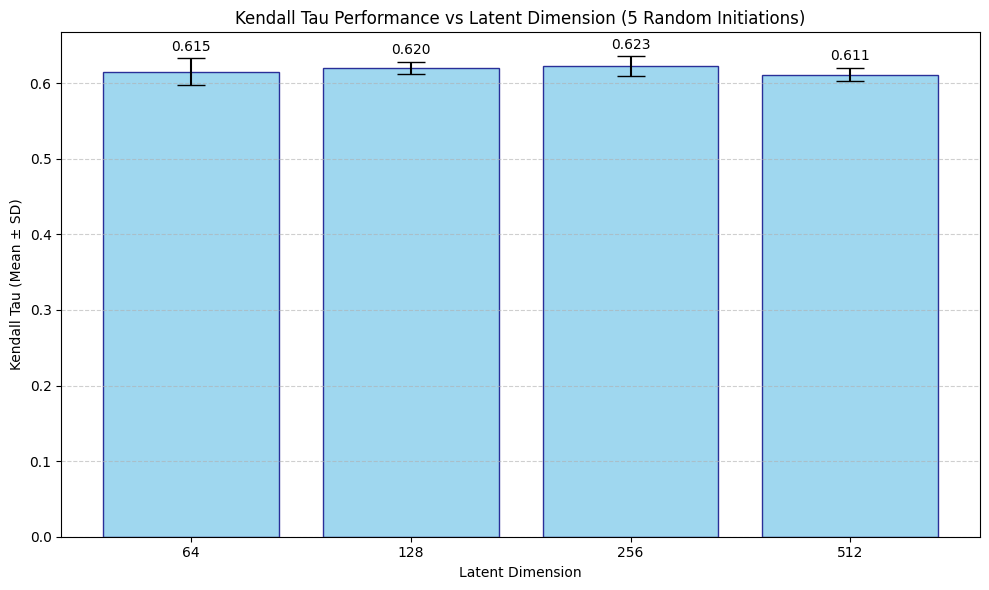

In [29]:
import seaborn as sns

plt.figure(figsize=(10, 6))

# Creating a bar chart for Kendall's Tau
# The yerr parameter now handles the variance (std) from 5 random initiations
plt.bar(sweep_df['latent_dim'].astype(str), sweep_df['tau_mean'],
        yerr=sweep_df['tau_std'], capsize=10, color='skyblue', edgecolor='navy', alpha=0.8)

plt.xlabel('Latent Dimension')
plt.ylabel('Kendall Tau (Mean ± SD)')
plt.title("Kendall Tau Performance vs Latent Dimension (5 Random Initiations)")
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the numeric values on top of bars for clarity
for i, row in sweep_df.iterrows():
    plt.text(i, row['tau_mean'] + row['tau_std'] + 0.01, f"{row['tau_mean']:.3f}", ha='center')

plt.tight_layout()
plt.show()

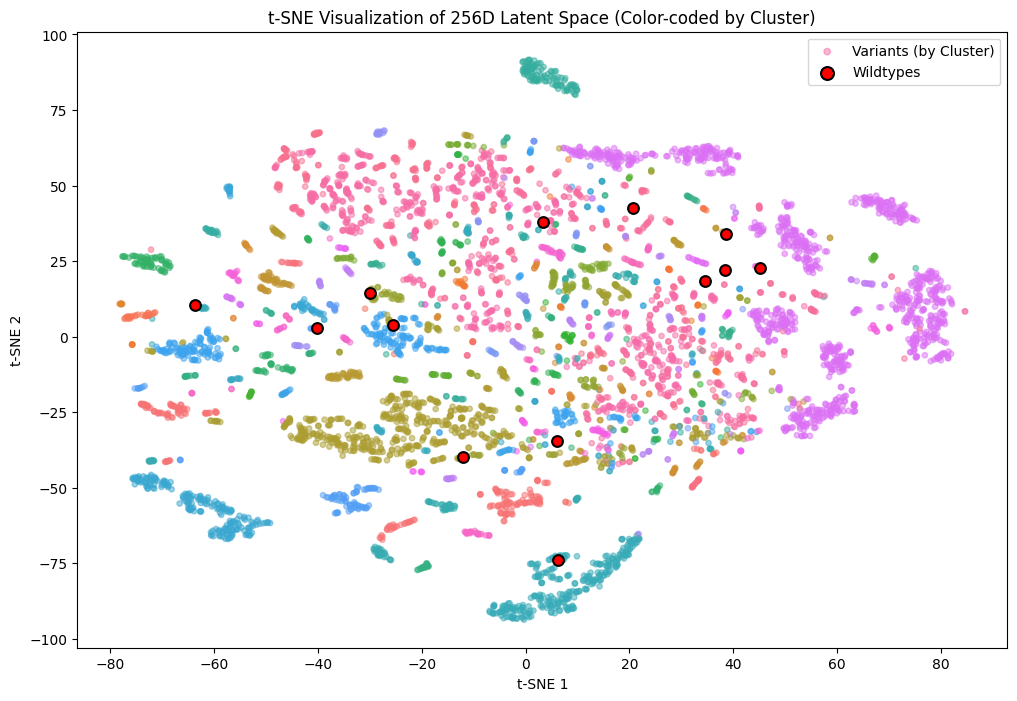

In [33]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_latent_space(model, dataset, device, num_samples=6000):
    model.eval()
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)

    all_z = []
    clusters = []
    is_wt = []

    with torch.no_grad():
        for idx in indices:
            emb = torch.from_numpy(np.array(dataset.embeddings[idx])).to(device).unsqueeze(0)
            h = model.encoder(emb)
            z = h[:, :model.latent_dim]
            all_z.append(z.cpu().numpy())

            cluster_id = dataset.clusters[idx]
            clusters.append(cluster_id)

            # Check if this specific sequence is the WT for its cluster
            curr_seq = dataset.sequences[idx]
            if cluster_id in dataset.wt_lookup and dataset.wt_lookup[cluster_id]['seq'] == curr_seq:
                is_wt.append(True)
            else:
                is_wt.append(False)

    z_map = np.vstack(all_z)
    tsne = TSNE(n_components=2, random_state=42)
    z_2d = tsne.fit_transform(z_map)

    plt.figure(figsize=(12, 8))

    # Map cluster IDs to colors
    unique_clusters = sorted(list(set(clusters)))
    palette = sns.color_palette("husl", len(unique_clusters))
    cluster_color_map = {c: palette[i] for i, c in enumerate(unique_clusters)}
    point_colors = [cluster_color_map[c] for c in clusters]

    # Plot variants colored by cluster
    plt.scatter(z_2d[:, 0], z_2d[:, 1],
                alpha=0.5, s=15, c=point_colors, label='Variants (by Cluster)')

    # Overlay Wildtypes prominently
    is_wt_mask = np.array(is_wt)
    plt.scatter(z_2d[is_wt_mask, 0], z_2d[is_wt_mask, 1],
                alpha=1.0, s=60, c='red', edgecolors='black', linewidth=1.5, label='Wildtypes')

    plt.title(f't-SNE Visualization of {model.latent_dim}D Latent Space (Color-coded by Cluster)')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(loc='upper right', markerscale=1.2)
    plt.show()

# Visualize using the main trained model
visualize_latent_space(model, val_ds, device)

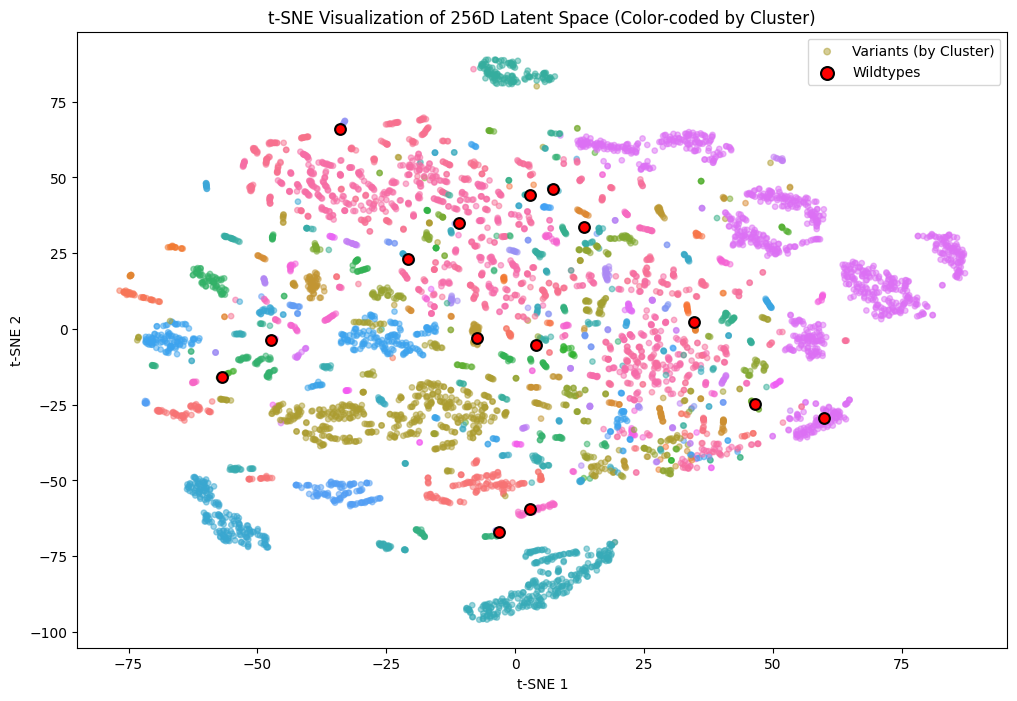

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figures saved and download started.


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 1. Save Latent Dimension Comparison
plt.figure(figsize=(10, 6))
plt.bar(sweep_df['latent_dim'].astype(str), sweep_df['tau_mean'],
        yerr=sweep_df['tau_std'], capsize=10, color='skyblue', edgecolor='navy', alpha=0.8)
plt.xlabel('Latent Dimension')
plt.ylabel('Kendall Tau (Mean ± SD)')
plt.title("Kendall Tau Performance vs Latent Dimension")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('latent_dim_comparison.svg', format='svg')
plt.close()

# 2. Save Latent Space t-SNE
# Note: This will re-run the t-SNE calculation to ensure we have the plot object
visualize_latent_space(model, val_ds, device, num_samples=6000)
plt.savefig('latent_space_tsne.svg', format='svg')
plt.close()

# Download both files
files.download('latent_dim_comparison.svg')
files.download('latent_space_tsne.svg')

print("Figures saved and download started.")